##AI Misinformation Detection on Social Media — Full ML Pipeline

In [ ]:
import numpy as np
import pandas as pd

###Dataset Creation Code

In [ ]:
'''

np.random.seed(42)
N = 5000

def generate_dataset(n):
    label = np.random.binomial(1, 0.45, n)           # ~45% misinformation

    # --- Account features ---
    user_followers    = np.where(label, np.random.randint(50,  3000,  n),
                                        np.random.randint(500, 50000, n))
    account_age_days  = np.where(label, np.random.randint(10,  400,   n),
                                        np.random.randint(180, 3000,  n))
    verified_account  = np.where(label, np.random.binomial(1, 0.05, n),
                                        np.random.binomial(1, 0.30, n))
    bot_probability   = np.where(label,
                                 np.clip(np.random.beta(5, 2, n), 0, 1),
                                 np.clip(np.random.beta(1, 8, n), 0, 1))
    previous_fake     = np.where(label, np.random.poisson(3, n),
                                        np.random.poisson(0.2, n))

    # --- Content features ---
    post_length       = np.where(label, np.random.randint(20,  180,  n),
                                        np.random.randint(60,  400,  n))
    num_hashtags      = np.where(label, np.random.randint(3,   12,   n),
                                        np.random.randint(0,   5,    n))
    num_links         = np.where(label, np.random.randint(1,   6,    n),
                                        np.random.randint(0,   3,    n))
    sentiment_score   = np.where(label,
                                 np.random.uniform(-1, -0.1, n),
                                 np.random.uniform(-0.3, 1,  n))
    ai_text_prob      = np.where(label,
                                 np.clip(np.random.beta(6, 2, n), 0, 1),
                                 np.clip(np.random.beta(1, 6, n), 0, 1))

    # --- Engagement features ---
    likes             = np.where(label, np.random.randint(0,   800,   n),
                                        np.random.randint(50,  5000,  n))
    shares            = np.where(label, np.random.randint(100, 3000,  n),
                                        np.random.randint(10,  1000,  n))
    comments          = np.where(label, np.random.randint(5,   300,   n),
                                        np.random.randint(10,  800,   n))

    # --- Platform features ---
    platforms         = np.random.choice(["Twitter","Instagram","TikTok","Facebook"], n,
                                         p=[0.35, 0.25, 0.20, 0.20])
    post_time_hour    = np.random.randint(0, 24, n)
    media_types       = np.random.choice(["text","image","video"], n, p=[0.45, 0.35, 0.20])
    topics            = np.random.choice(
                            ["politics","war","technology","health","climate","economics"], n,
                            p=[0.25, 0.20, 0.15, 0.20, 0.10, 0.10])

    # Aggressive noise: scramble 35% of rows and flip 8% of labels
    for arr in [bot_probability, ai_text_prob]:
        idx = np.random.choice(n, int(n*0.35), replace=False)
        arr[idx] = np.random.uniform(0, 1, len(idx))
    idx = np.random.choice(n, int(n*0.35), replace=False)
    sentiment_score[idx] = np.random.uniform(-1, 1, len(idx))
    for arr in [shares, likes]:
        idx = np.random.choice(n, int(n*0.35), replace=False)
        arr[idx] = np.random.randint(0, 5000, len(idx))
    flip_idx = np.random.choice(n, int(n*0.08), replace=False)
    label[flip_idx] = 1 - label[flip_idx]


    df = pd.DataFrame({
        "user_followers":    user_followers,
        "account_age_days":  account_age_days,
        "verified_account":  verified_account,
        "bot_probability":   np.round(bot_probability, 3),
        "previous_fake_posts": previous_fake,
        "post_length":       post_length,
        "num_hashtags":      num_hashtags,
        "num_links":         num_links,
        "sentiment_score":   np.round(sentiment_score, 3),
        "ai_text_probability": np.round(ai_text_prob, 3),
        "likes":             likes,
        "shares":            shares,
        "comments":          comments,
        "platform":          platforms,
        "post_time_hour":    post_time_hour,
        "media_type":        media_types,
        "topic_category":    topics,
        "is_misinformation": label,
    })
    return df

df = generate_dataset(N)
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['is_misinformation'].value_counts()}")

'''

'\n\nnp.random.seed(42)\nN = 5000\n\ndef generate_dataset(n):\n    label = np.random.binomial(1, 0.45, n)           # ~45% misinformation\n\n    # --- Account features ---\n    user_followers    = np.where(label, np.random.randint(50,  3000,  n),\n                                        np.random.randint(500, 50000, n))\n    account_age_days  = np.where(label, np.random.randint(10,  400,   n),\n                                        np.random.randint(180, 3000,  n))\n    verified_account  = np.where(label, np.random.binomial(1, 0.05, n),\n                                        np.random.binomial(1, 0.30, n))\n    bot_probability   = np.where(label,\n                                 np.clip(np.random.beta(5, 2, n), 0, 1),\n                                 np.clip(np.random.beta(1, 8, n), 0, 1))\n    previous_fake     = np.where(label, np.random.poisson(3, n),\n                                        np.random.poisson(0.2, n))\n\n    # --- Content features ---\n    post_length       = 

###Dataset that has been created through Code, into csv file

In [ ]:
#df.to_csv("Social_media_info.csv")

###Reading the csv file and storing into df variable.

In [ ]:
df=pd.read_csv("Social_media_info.csv")

In [ ]:
np.random.seed(42)
N = 5000


for col in ["bot_probability", "sentiment_score", "ai_text_probability"]:
    mask = np.random.random(N) < 0.03
    df.loc[mask, col] = np.nan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           5000 non-null   int64  
 1   user_followers       5000 non-null   int64  
 2   account_age_days     5000 non-null   int64  
 3   verified_account     5000 non-null   int64  
 4   bot_probability      4852 non-null   float64
 5   previous_fake_posts  5000 non-null   int64  
 6   post_length          5000 non-null   int64  
 7   num_hashtags         5000 non-null   int64  
 8   num_links            5000 non-null   int64  
 9   sentiment_score      4860 non-null   float64
 10  ai_text_probability  4851 non-null   float64
 11  likes                5000 non-null   int64  
 12  shares               5000 non-null   int64  
 13  comments             5000 non-null   int64  
 14  platform             5000 non-null   object 
 15  post_time_hour       5000 non-null   i

In [ ]:
df.describe()

,Unnamed: 0,user_followers,account_age_days,verified_account,bot_probability,previous_fake_posts,post_length,num_hashtags,num_links,sentiment_score,ai_text_probability,likes,shares,comments,post_time_hour,is_misinformation
count,5000.000000,5000.000000,5000.000000,5000.000000,4852.000000,5000.000000,5000.000000,5000.000000,5000.000000,4860.000000,4851.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,14368.502200,973.588800,0.181600,0.431219,1.453000,171.282800,4.288200,1.914400,-0.039447,0.446788,1929.496600,1526.502200,291.022000,11.477400,0.455200
std,1443.520003,15672.237802,923.901595,0.385553,0.316276,1.854637,101.616867,3.234754,1.524709,0.561712,0.318732,1559.814454,1296.500777,217.553766,6.873233,0.498039
min,0.000000,52.000000,10.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,-0.999000,0.000000,1.000000,8.000000,5.000000,0.000000,0.000000
25%,1249.750000,1563.000000,218.000000,0.000000,0.114000,0.000000,92.750000,2.000000,1.000000,-0.494000,0.132500,493.750000,508.750000,123.000000,6.000000,0.000000
50%,2499.500000,5009.000000,436.000000,0.000000,0.414000,1.000000,148.000000,4.000000,2.000000,-0.107000,0.428000,1589.500000,985.000000,231.000000,12.000000,0.000000
75%,3749.250000,26476.000000,1751.250000,0.000000,0.727250,3.000000,242.000000,7.000000,3.000000,0.429250,0.749000,3331.000000,2358.250000,433.250000,17.000000,1.000000
max,4999.000000,49982.000000,2998.000000,1.000000,1.000000,11.000000,399.000000,11.000000,5.000000,0.999000,1.000000,4999.000000,4998.000000,799.000000,23.000000,1.000000


In [ ]:
df.head()

,Unnamed: 0,user_followers,account_age_days,verified_account,bot_probability,previous_fake_posts,post_length,num_hashtags,num_links,sentiment_score,ai_text_probability,likes,shares,comments,platform,post_time_hour,media_type,topic_category,is_misinformation
0,0,38305,496,0,0.143,1,107,1,2,-0.144,0.011,3074,60,360,Twitter,11,image,politics,0
1,1,529,75,0,0.472,3,35,11,3,-0.503,0.824,775,2185,212,Instagram,10,text,war,1
2,2,1847,374,0,0.259,2,38,10,5,-0.474,0.937,101,798,164,Twitter,14,image,politics,1
3,3,2181,288,0,0.013,5,40,11,1,-0.384,0.867,2137,3110,156,Twitter,21,image,economics,1
4,4,29763,2956,0,0.402,0,319,3,2,-0.200,0.243,1422,489,126,Twitter,7,text,technology,1


####Two Columns Named Unnamed were found in dataset, which are No use for the Model, Those Two Columns were Dropped

In [ ]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
df

,user_followers,account_age_days,verified_account,bot_probability,previous_fake_posts,post_length,num_hashtags,num_links,sentiment_score,ai_text_probability,likes,shares,comments,platform,post_time_hour,media_type,topic_category,is_misinformation
0,38305,496,0,0.143,1,107,1,2,-0.144,0.011,3074,60,360,Twitter,11,image,politics,0
1,529,75,0,0.472,3,35,11,3,-0.503,0.824,775,2185,212,Instagram,10,text,war,1
2,1847,374,0,0.259,2,38,10,5,-0.474,0.937,101,798,164,Twitter,14,image,politics,1
3,2181,288,0,0.013,5,40,11,1,-0.384,0.867,2137,3110,156,Twitter,21,image,economics,1
4,29763,2956,0,0.402,0,319,3,2,-0.200,0.243,1422,489,126,Twitter,7,text,technology,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,842,267,0,0.814,0,161,10,3,-0.965,0.937,345,2892,106,Facebook,18,text,technology,1
4996,43141,2680,0,0.197,0,359,1,0,0.483,0.675,3408,781,769,Twitter,14,text,climate,0
4997,26409,2973,0,0.039,1,288,0,0,-0.038,0.649,176,558,216,Twitter,2,text,health,1
4998,1055,236,0,0.729,1,23,8,4,0.211,0.581,4084,1146,256,Facebook,9,text,climate,1


In [ ]:
df.head()

,user_followers,account_age_days,verified_account,bot_probability,previous_fake_posts,post_length,num_hashtags,num_links,sentiment_score,ai_text_probability,likes,shares,comments,platform,post_time_hour,media_type,topic_category,is_misinformation
0,38305,496,0,0.143,1,107,1,2,-0.144,0.011,3074,60,360,Twitter,11,image,politics,0
1,529,75,0,0.472,3,35,11,3,-0.503,0.824,775,2185,212,Instagram,10,text,war,1
2,1847,374,0,0.259,2,38,10,5,-0.474,0.937,101,798,164,Twitter,14,image,politics,1
3,2181,288,0,0.013,5,40,11,1,-0.384,0.867,2137,3110,156,Twitter,21,image,economics,1
4,29763,2956,0,0.402,0,319,3,2,-0.200,0.243,1422,489,126,Twitter,7,text,technology,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_followers       5000 non-null   int64  
 1   account_age_days     5000 non-null   int64  
 2   verified_account     5000 non-null   int64  
 3   bot_probability      4852 non-null   float64
 4   previous_fake_posts  5000 non-null   int64  
 5   post_length          5000 non-null   int64  
 6   num_hashtags         5000 non-null   int64  
 7   num_links            5000 non-null   int64  
 8   sentiment_score      4860 non-null   float64
 9   ai_text_probability  4851 non-null   float64
 10  likes                5000 non-null   int64  
 11  shares               5000 non-null   int64  
 12  comments             5000 non-null   int64  
 13  platform             5000 non-null   object 
 14  post_time_hour       5000 non-null   int64  
 15  media_type           5000 non-null   o

In [ ]:
df.shape

(5000, 18)

In [ ]:
df.isnull().sum()

,0
user_followers,0
account_age_days,0
verified_account,0
bot_probability,148
previous_fake_posts,0
post_length,0
num_hashtags,0
num_links,0
sentiment_score,140
ai_text_probability,149


###The columns that have null values are :

1. bot_probability
2. sentiment_score
3. ai_text_probability

In [ ]:
cols = ['bot_probability','sentiment_score','ai_text_probability']

for i in cols:
  print(df[i].describe())
  print("Null Values : ",df[i].isnull().sum())
  print("\n")

count    4852.000000
mean        0.431219
std         0.316276
min         0.000000
25%         0.114000
50%         0.414000
75%         0.727250
max         1.000000
Name: bot_probability, dtype: float64
Null Values :  148


count    4860.000000
mean       -0.039447
std         0.561712
min        -0.999000
25%        -0.494000
50%        -0.107000
75%         0.429250
max         0.999000
Name: sentiment_score, dtype: float64
Null Values :  140


count    4851.000000
mean        0.446788
std         0.318732
min         0.000000
25%         0.132500
50%         0.428000
75%         0.749000
max         1.000000
Name: ai_text_probability, dtype: float64
Null Values :  149




In [ ]:
for i in cols:
  df.fillna(df[i].median(), inplace=True)

###NOW, ALL THE NULL VALUES ARE HANDLED

In [ ]:
df.isnull().sum()

,0
user_followers,0
account_age_days,0
verified_account,0
bot_probability,0
previous_fake_posts,0
post_length,0
num_hashtags,0
num_links,0
sentiment_score,0
ai_text_probability,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
cols = ['platform','media_type','topic_category','is_misinformation']

for i in cols:
  print(df[i].value_counts())
  print("\n")

platform
Twitter      1699
Instagram    1251
TikTok       1056
Facebook      994
Name: count, dtype: int64


media_type
text     2275
image    1763
video     962
Name: count, dtype: int64


topic_category
politics      1279
war            994
health         994
technology     721
climate        514
economics      498
Name: count, dtype: int64


is_misinformation
0    2724
1    2276
Name: count, dtype: int64




### Now Categorical Columns, should be Converted into Numerical Form before giving it to model.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
for col in ["platform", "media_type", "topic_category"]:
    df[col + "_enc"] = le.fit_transform(df[col])

In [ ]:
df.head()

,user_followers,account_age_days,verified_account,bot_probability,previous_fake_posts,post_length,num_hashtags,num_links,sentiment_score,ai_text_probability,...,shares,comments,platform,post_time_hour,media_type,topic_category,is_misinformation,platform_enc,media_type_enc,topic_category_enc
0,38305,496,0,0.143,1,107,1,2,-0.144,0.011,...,60,360,Twitter,11,image,politics,0,3,0,3
1,529,75,0,0.472,3,35,11,3,-0.503,0.824,...,2185,212,Instagram,10,text,war,1,1,1,5
2,1847,374,0,0.259,2,38,10,5,-0.474,0.937,...,798,164,Twitter,14,image,politics,1,3,0,3
3,2181,288,0,0.013,5,40,11,1,-0.384,0.867,...,3110,156,Twitter,21,image,economics,1,3,0,1
4,29763,2956,0,0.402,0,319,3,2,-0.200,0.243,...,489,126,Twitter,7,text,technology,1,3,1,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_followers       5000 non-null   int64  
 1   account_age_days     5000 non-null   int64  
 2   verified_account     5000 non-null   int64  
 3   bot_probability      5000 non-null   float64
 4   previous_fake_posts  5000 non-null   int64  
 5   post_length          5000 non-null   int64  
 6   num_hashtags         5000 non-null   int64  
 7   num_links            5000 non-null   int64  
 8   sentiment_score      5000 non-null   float64
 9   ai_text_probability  5000 non-null   float64
 10  likes                5000 non-null   int64  
 11  shares               5000 non-null   int64  
 12  comments             5000 non-null   int64  
 13  platform             5000 non-null   object 
 14  post_time_hour       5000 non-null   int64  
 15  media_type           5000 non-null   o

###OLD COLUMNS HAVING CATEGORICAL RECORDS SHOULD BE DROPPED

In [ ]:
for col in ["platform", "media_type", "topic_category"]:
    df.drop(col, axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_followers       5000 non-null   int64  
 1   account_age_days     5000 non-null   int64  
 2   verified_account     5000 non-null   int64  
 3   bot_probability      5000 non-null   float64
 4   previous_fake_posts  5000 non-null   int64  
 5   post_length          5000 non-null   int64  
 6   num_hashtags         5000 non-null   int64  
 7   num_links            5000 non-null   int64  
 8   sentiment_score      5000 non-null   float64
 9   ai_text_probability  5000 non-null   float64
 10  likes                5000 non-null   int64  
 11  shares               5000 non-null   int64  
 12  comments             5000 non-null   int64  
 13  post_time_hour       5000 non-null   int64  
 14  is_misinformation    5000 non-null   int64  
 15  platform_enc         5000 non-null   i

##FEATURE ENGINEERING

In [ ]:

df.columns

Index(['user_followers', 'account_age_days', 'verified_account',
       'bot_probability', 'previous_fake_posts', 'post_length', 'num_hashtags',
       'num_links', 'sentiment_score', 'ai_text_probability', 'likes',
       'shares', 'comments', 'post_time_hour', 'is_misinformation',
       'platform_enc', 'media_type_enc', 'topic_category_enc'],
      dtype='object')

###Feature Engineering - Engagement Rate

initially, thought of this formula...

`df["engagement_rate"]     = (df["likes"] + df["shares"] + df["comments"]) / (df["user_followers"])`


then, later understood that ZERO DIVISION PROBLEM might happen.(if user_followers = 0)

so, to solve that, added +1 to Denominator

`df["engagement_rate"]     = (df["likes"] + df["shares"] + df["comments"]) / (df["user_followers"] + 1)`

but, then another problem exists , that.. +1 might give extremely High engagement rate for some (like for users with zero followers)

so, to solve that, i made some variation in formula



`
df['engagement_rate'] = ( df['likes'] + df['shares'] + df['comments'] ) / df['user_followers'].clip(lower=10)
`

Adding a separate feature for suspicious accounts...

`df['low_follower_flag'] = df['user_followers'] < 5`



In [ ]:
df['engagement_rate'] = ( df['likes'] + df['shares'] + df['comments'] ) / df['user_followers'].clip(lower=10)

In [ ]:
df['low_follower_flag'] = df['user_followers'] < 5

###Feature Engineering - Viral Ratio

Initially the formula was..

`df["viral_ratio"] = df["shares"] / (df["likes"]  + 1)`

Then, as 'likes' are important, similarly the 'comments' play a significant role to decide it's virality

`df["viral_ratio"] = df["shares"] / (df["likes"] + df["comments"] + 1)`

In [ ]:
df["viral_ratio"] = df["shares"] / (df["likes"] + df["comments"] + 1)

###Feature Engineering - Account Authenticity

Initially, The formula :

`df["account_trust_score"] = (1 - df["bot_probability"]) * (df["account_age_days"] / 3000)`


Then, assigned weights to it ...

also added another features(prevfakeposts) to the formula..

```
account_authenticity = ((1 - bot_probability) * 0.6) + ((account_age_days / 3000) * 0.3)-(min (previous_fake_posts * 0.01 , 0.2))
```

why, 0.2 -> cuz, right now which dataset we are using its max value for prev_fake_posts feature is 11.

In [ ]:
df["account_authenticity"] = (
    (1 - df["bot_probability"]) * 0.6
    + (df["account_age_days"] / 3000) * 0.3
    - (df["previous_fake_posts"] * 0.01).clip(upper=0.2)
)

In [ ]:
df.head()

,user_followers,account_age_days,verified_account,bot_probability,previous_fake_posts,post_length,num_hashtags,num_links,sentiment_score,ai_text_probability,...,comments,post_time_hour,is_misinformation,platform_enc,media_type_enc,topic_category_enc,engagement_rate,low_follower_flag,viral_ratio,account_authenticity
0,38305,496,0,0.143,1,107,1,2,-0.144,0.011,...,360,11,0,3,0,3,0.091215,False,0.017467,0.5538
1,529,75,0,0.472,3,35,11,3,-0.503,0.824,...,212,10,1,1,1,5,5.996219,False,2.211538,0.2943
2,1847,374,0,0.259,2,38,10,5,-0.474,0.937,...,164,14,1,3,0,3,0.575528,False,3.000000,0.4620
3,2181,288,0,0.013,5,40,11,1,-0.384,0.867,...,156,21,1,3,0,1,2.477304,False,1.355711,0.5710
4,29763,2956,0,0.402,0,319,3,2,-0.200,0.243,...,126,7,1,3,1,4,0.068441,False,0.315688,0.6544


###DATA VISUALISATION

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

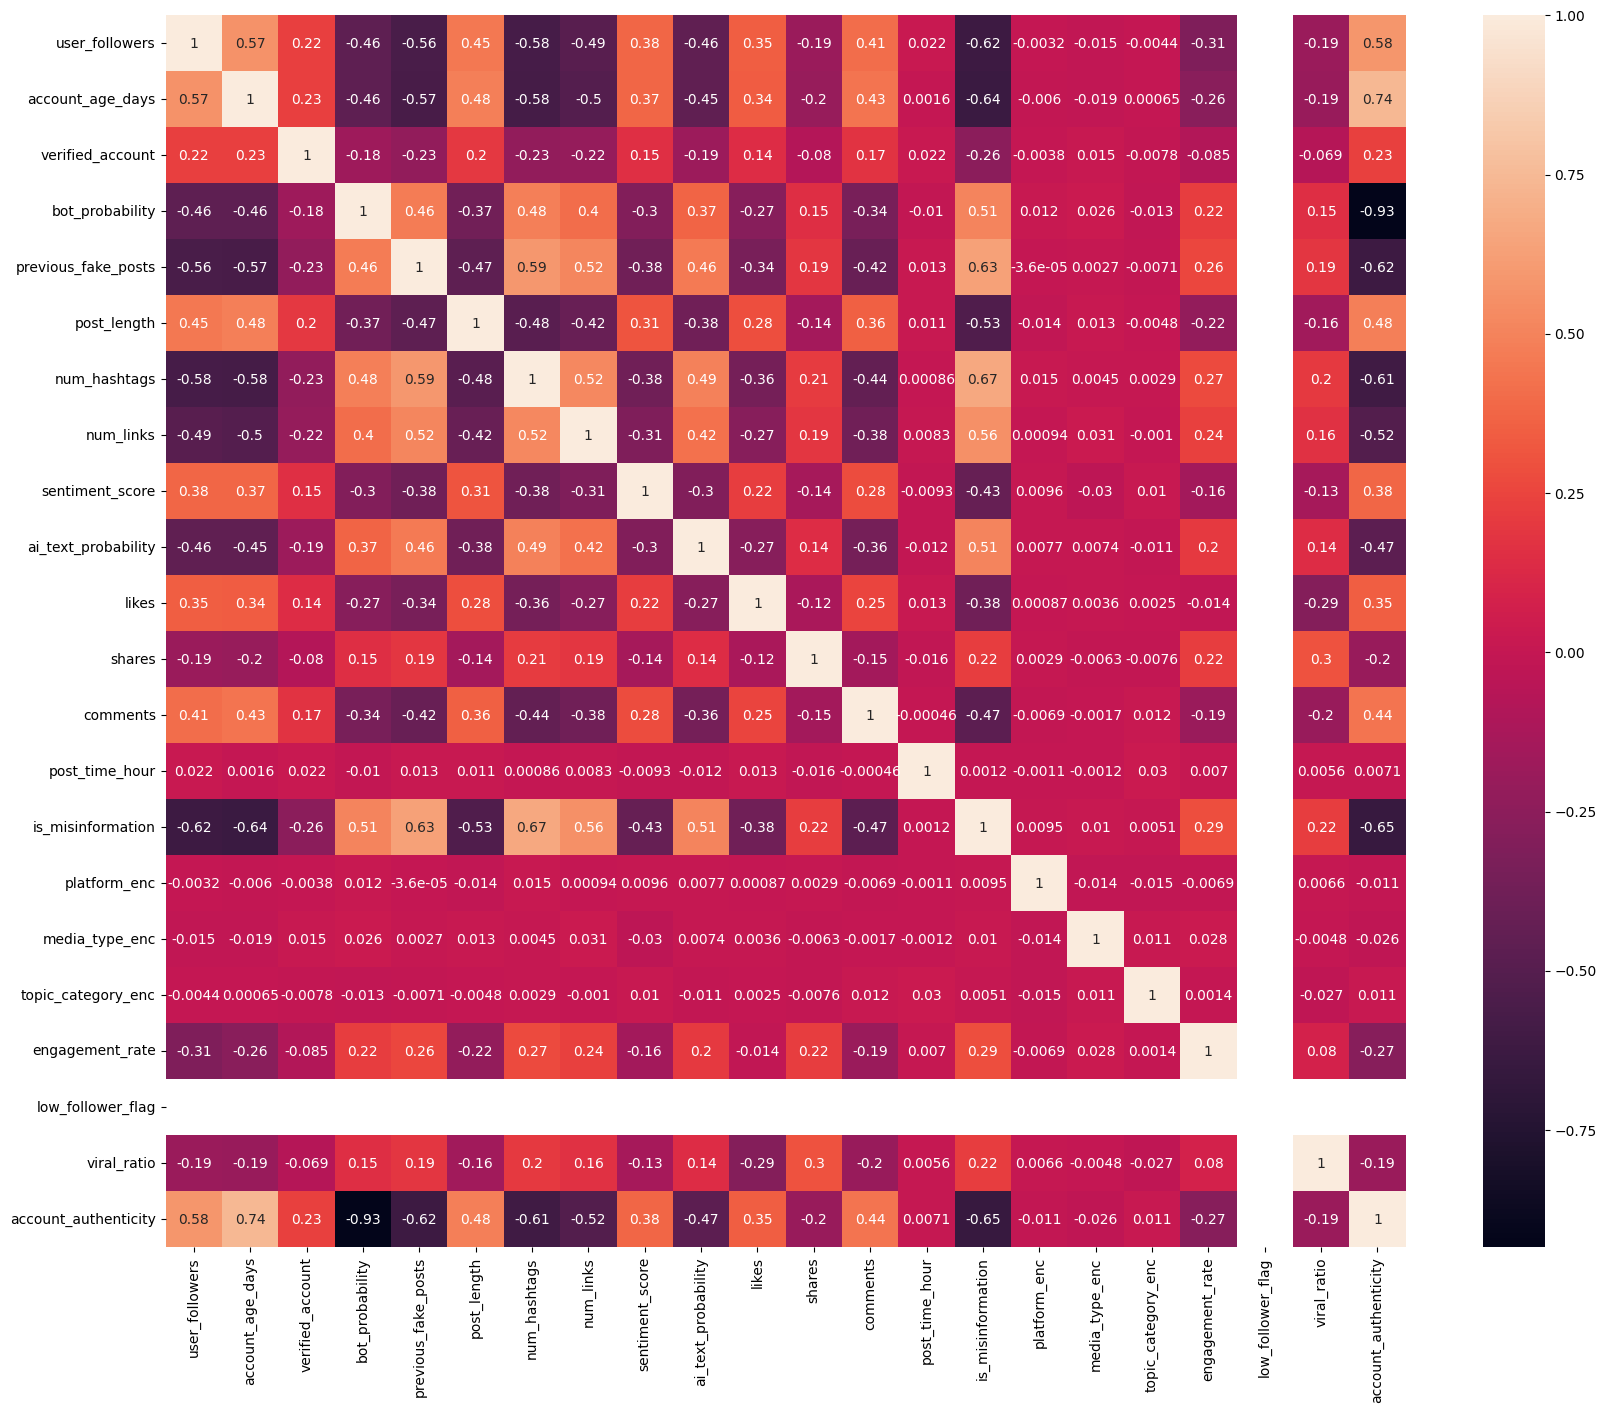

In [ ]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
# Consistent style
PALETTE = {"real": "#4CAF50", "fake": "#E53935"}
BG      = "#F8F9FA"
ACCENT  = "#1A237E"
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

labels_map = {0: "Real", 1: "Fake"}
colors     = [PALETTE["real"], PALETTE["fake"]]


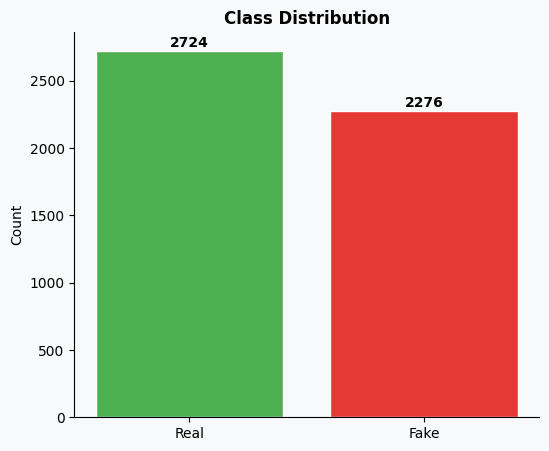

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

counts = df["is_misinformation"].value_counts().sort_index()

bars = plt.bar(
    ["Real", "Fake"],
    counts.values, #value of the created variable
    color=["#4CAF50", "#E53935"],
    edgecolor="white"
)

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 30,
        value,
        ha="center",
        fontweight="bold"
    )

plt.title("Class Distribution", fontweight="bold")
plt.ylabel("Count")

plt.show()

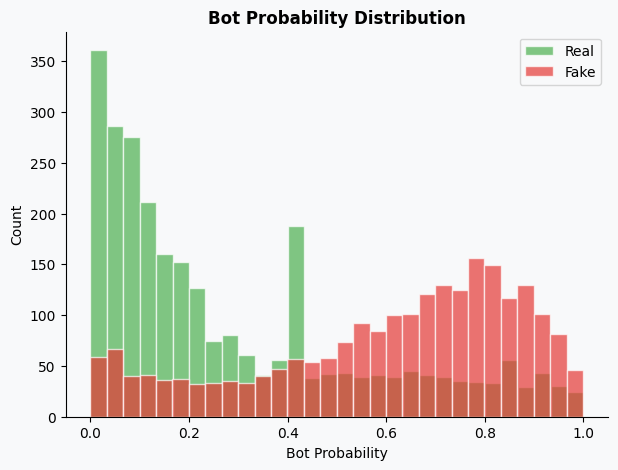

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for val, label in [(0, "Real"), (1, "Fake")]:
    subset = df[df["is_misinformation"] == val]["bot_probability"]

    plt.hist(
        subset, #variable made above
        bins=30,  #30 bins for histogram
        alpha=0.7, #transparency
        label=label, #real,fake labels
        color=colors[val], #green,red(mentioned above)
        edgecolor="white"  ##white edges
    )

plt.title("Bot Probability Distribution", fontweight="bold")
plt.xlabel("Bot Probability")
plt.ylabel("Count")
plt.legend()

plt.show()

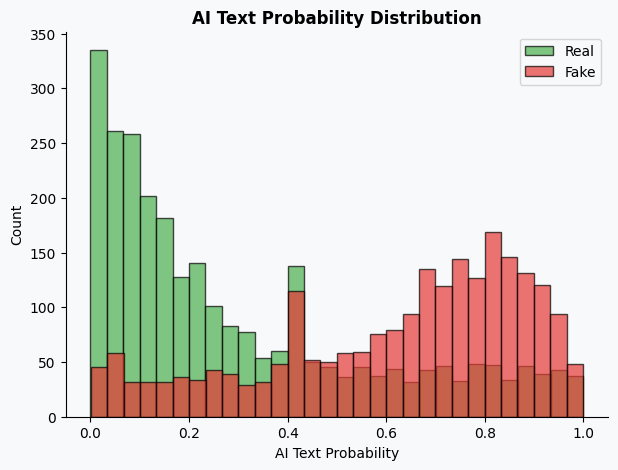

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for val, label in [(0, "Real"), (1, "Fake")]:
    subset = df[df["is_misinformation"] == val]["ai_text_probability"]

    plt.hist(
        subset,  #variable made above
        bins=30,  #30 bins for histogram
        alpha=0.7,  #transparency
        label=label,  #real,fake labels
        color=colors[val],  #green,red(mentioned above)
        edgecolor="black"  #black edges
    )


plt.title("AI Text Probability Distribution", fontweight="bold")
plt.xlabel("AI Text Probability")
plt.ylabel("Count")
plt.legend()

plt.show()

/tmp/ipykernel_163/1200539083.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


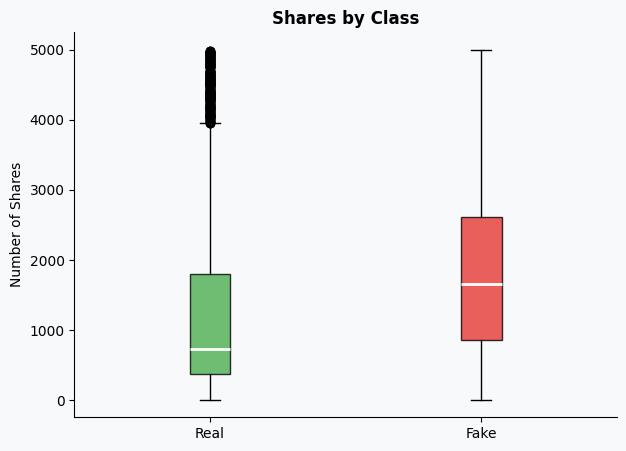

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

data_box = [
    df[df["is_misinformation"] == 0]["shares"],
    df[df["is_misinformation"] == 1]["shares"]
]

bp = plt.boxplot(
    data_box,
    labels=["Real", "Fake"],
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2)
)

colors = ["#4CAF50", "#E53935"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.title("Shares by Class", fontweight="bold")
plt.ylabel("Number of Shares")

plt.show()

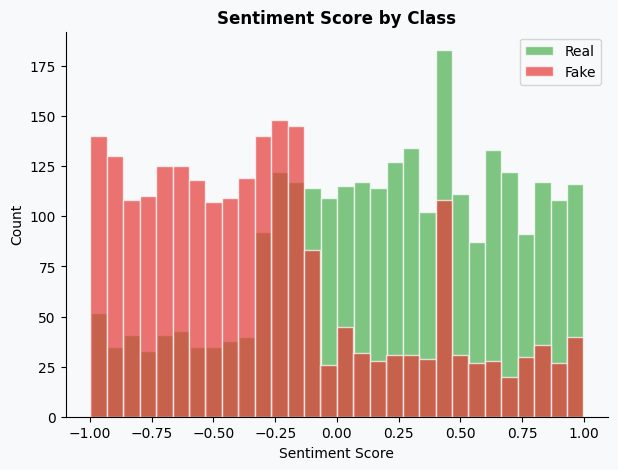

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

colors = ["#4CAF50", "#E53935"]

for val, label in [(0, "Real"), (1, "Fake")]:
    subset = df[df["is_misinformation"] == val]["sentiment_score"]

    plt.hist(
        subset,
        bins=30,
        alpha=0.7,
        label=label,
        color=colors[val],
        edgecolor="white"
    )

plt.title("Sentiment Score by Class", fontweight="bold")
plt.xlabel("Sentiment Score")
plt.ylabel("Count")
plt.legend()

plt.show()

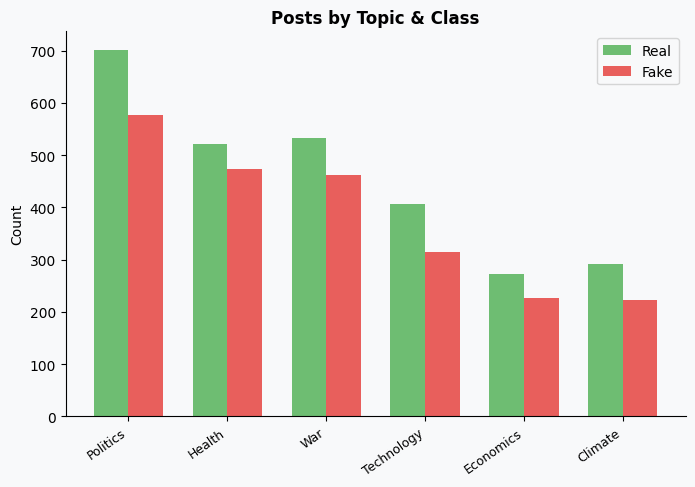

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

topic_names = { #alphabetical order
    0: "Climate",
    1: "Economics",
    2: "Health",
    3: "Politics",
    4: "Technology",
    5: "War"
}

plt.figure(figsize=(8,5))

topic_fake = df[df["is_misinformation"] == 1]["topic_category_enc"].value_counts()
topic_real = df[df["is_misinformation"] == 0]["topic_category_enc"].value_counts()

topics_list = topic_fake.index

x = np.arange(len(topics_list))
width = 0.35

plt.bar(
    x - width/2,
    topic_real[topics_list].values,
    width,
    label="Real",
    color="#4CAF50",
    alpha=0.8
)

plt.bar(
    x + width/2,
    topic_fake.values,
    width,
    label="Fake",
    color="#E53935",
    alpha=0.8
)

labels = [topic_names[i] for i in topics_list]

plt.xticks(x,labels, rotation=35, ha="right", fontsize=9)

plt.title("Posts by Topic & Class", fontweight="bold")
plt.ylabel("Count")
plt.legend()

plt.show()

In [ ]:
df.columns

Index(['user_followers', 'account_age_days', 'verified_account',
       'bot_probability', 'previous_fake_posts', 'post_length', 'num_hashtags',
       'num_links', 'sentiment_score', 'ai_text_probability', 'likes',
       'shares', 'comments', 'post_time_hour', 'is_misinformation',
       'platform_enc', 'media_type_enc', 'topic_category_enc',
       'engagement_rate', 'low_follower_flag', 'viral_ratio',
       'account_authenticity'],
      dtype='object')

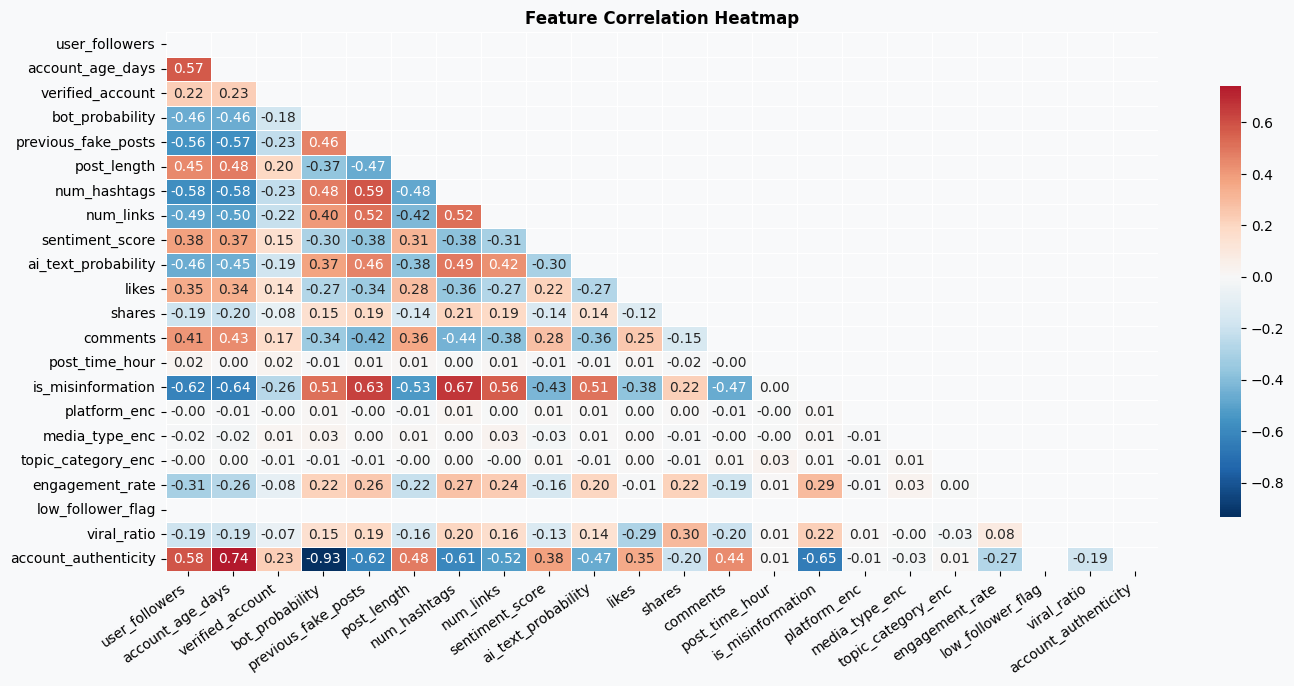

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(16,7))

num_cols = df.columns

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap", fontweight="bold")

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.show()

-----

##Model Creation

###Data Split

In [ ]:
X=df.drop('is_misinformation',axis=1)
y=df['is_misinformation']

In [ ]:
X.shape, y.shape

((5000, 21), (5000,))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


#LOGISTIC REGRESSION

In [ ]:
from sklearn.preprocessing import StandardScaler

#Standard Scaler To Scale The Features - To Test Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [ ]:
print(accuracy_score(y_test, lr.predict(X_test_sc)))

0.916


In [ ]:
print(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]))

0.9177578384917835


In [ ]:
print(classification_report(y_test, lr.predict(X_test_sc)))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, lr.predict(X_test_sc)))

[[509  36]
 [ 48 407]]


------

#Random Forest Default

### #Note: RandomForestClassifier Doesn't Require Feature scaling, as its a tree based algorithm

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_default = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
print(accuracy_score(y_test, rf_default.predict(X_test)))

0.917


In [ ]:
print(roc_auc_score(y_test, rf_default.predict_proba(X_test)[:, 1]))

0.9095553987297107


----

###Optimizing Using GridSearchCv

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
param_grid = {
    'n_estimators': [200],    #[50, 100, 200]
    'max_depth': [10, 20, 30],    #[None, 10, 20, 30]
    'max_features': ['sqrt','log2'],    #['sqrt','log2']
    'min_samples_split': [5,10],    #[2,5,10]
    'min_samples_leaf': [2,4],    #[1,2,4]
}

----

###GridSearchCv When Scoring = 'accuracy'

In [ ]:
grid_search_acc = GridSearchCV(
    estimator=rf_default,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs = -1,
    verbose=2
)

In [ ]:
grid_search_acc.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [5, 10], 'n_estimators': [200]},
             scoring='accuracy', verbose=2)

In [ ]:
grid_search_acc.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'n_estimators': 200}

In [ ]:
rf_tuned_acc= grid_search_acc.best_estimator_

In [ ]:
print(accuracy_score(y_test, rf_tuned_acc.predict(X_test)))

0.917


In [ ]:
print(roc_auc_score(y_test, rf_tuned_acc.predict_proba(X_test)[:, 1]))

0.9114789797358607


In [ ]:
print(classification_report(y_test, rf_tuned_acc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, rf_tuned_acc.predict(X_test)))

[[510  35]
 [ 48 407]]


----

###GridSearchCv When Scoring = 'roc_auc'

In [ ]:
grid_search_roc_auc = GridSearchCV(
    estimator=rf_default,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs = -1,
    verbose=2
)

In [ ]:
grid_search_roc_auc.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [5, 10], 'n_estimators': [200]},
             scoring='roc_auc', verbose=2)

In [ ]:
grid_search_roc_auc.best_params_

{'max_depth': 30,
 'max_features': 'sqrt',
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'n_estimators': 200}

In [ ]:
rf_tuned_roc_auc= grid_search_roc_auc.best_estimator_

In [ ]:
print(accuracy_score(y_test, rf_tuned_roc_auc.predict(X_test)))

0.917


In [ ]:
print(roc_auc_score(y_test, rf_tuned_roc_auc.predict_proba(X_test)[:, 1]))

0.910970863998387


In [ ]:
print(classification_report(y_test, rf_tuned_roc_auc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, rf_tuned_roc_auc.predict(X_test)))

[[510  35]
 [ 48 407]]


****

###RandomizedSearchCV When Scoring = 'roc_auc'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from scipy.stats import randint

In [ ]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 50),
    'min_samples_split': randint(2, 10),
}

In [ ]:
random_search_roc_auc = RandomizedSearchCV(
    estimator=rf_default,
    param_distributions=param_dist,   # same dictionary you used before
    n_iter=50,                        # number of random combinations to try
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [ ]:
random_search_roc_auc.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fbcc6c7ef60>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fbcc6c7eed0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fbcc6b2f740>},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print(random_search_roc_auc.best_params_)

{'max_depth': 38, 'min_samples_split': 2, 'n_estimators': 147}


In [ ]:
rf_tuned_RS_roc_auc = random_search_roc_auc.best_estimator_

In [ ]:
print(accuracy_score(y_test, rf_tuned_RS_roc_auc.predict(X_test)))

0.916


In [ ]:
print(roc_auc_score(y_test, rf_tuned_RS_roc_auc.predict_proba(X_test)[:, 1]))

0.9088315354370399


In [ ]:
print(classification_report(y_test, rf_tuned_RS_roc_auc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, rf_tuned_RS_roc_auc.predict(X_test)))

[[509  36]
 [ 48 407]]


-----

###XGBClassifier

In [ ]:
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:35:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
print("Accuracy :", accuracy_score(y_test, xgb_model.predict(X_test)))

Accuracy : 0.915


In [ ]:
print("ROC-AUC  :", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

ROC-AUC  : 0.9074301844944047


In [ ]:
print(classification_report(y_test, xgb_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.92      0.91      1000



In [ ]:
print(confusion_matrix(y_test, xgb_model.predict(X_test)))

[[508  37]
 [ 48 407]]


-----

###XGBClassifier RandomizedSeacrchCV

In [ ]:
xgb_param_dist = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 5),
    "min_child_weight": randint(1, 10)
}

In [ ]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

In [ ]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:47:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fbcc5e106b0>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fbcc5e11dc0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7fbcc5e11a00>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7fbcc5e117c0>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
best_xgb = xgb_search.best_estimator_

print("Best params:", xgb_search.best_params_)
print("Best CV AUC:", xgb_search.best_score_)

Best params: {'colsample_bytree': np.float64(0.9350840423629312), 'gamma': np.float64(3.3784505851964037), 'learning_rate': np.float64(0.23056483577223164), 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 514, 'subsample': np.float64(0.9509357413523924)}
Best CV AUC: 0.9276244191436703


In [ ]:
print("Accuracy :", accuracy_score(y_test, best_xgb.predict(X_test)))


Accuracy : 0.916


In [ ]:
print("ROC-AUC  :", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]))


ROC-AUC  : 0.9176650872063716


In [ ]:
print(classification_report(y_test, best_xgb.predict(X_test)))


              precision    recall  f1-score   support

           0       0.91      0.93      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000



In [ ]:
print(confusion_matrix(y_test, best_xgb.predict(X_test)))

[[509  36]
 [ 48 407]]


------

##Model Comparisions

In [ ]:
models = {
    "Logistic Regression": lr,
    "Random Forest Default": rf_default,
    "Random Forest GridSearchCV Accuracy": rf_tuned_acc,
    "Random Forest GridSearchCV ROC-AUC": rf_tuned_roc_auc,
    "Random Forest RandomizedSearchCV ROC-AUC": rf_tuned_RS_roc_auc,
    "XGBoost Default": xgb_model,
    "XGBoost RandomizedSearchCV ROC-AUC": best_xgb
}

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

results = []

for name, model in models.items():
    # Logistic Regression requires the scaled test set
    if name == "Logistic Regression":
        current_X_test = X_test_sc
    else:
        current_X_test = X_test

    y_pred = model.predict(current_X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(current_X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC_AUC": roc
    })

    print("-" * 75)
    print(f"{name}")
    print("Classification Report")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 75)

print("Evaluation complete.")

---------------------------------------------------------------------------
Logistic Regression
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.92      1000
weighted avg       0.92      0.92      0.92      1000

Confusion Matrix
[[509  36]
 [ 48 407]]
---------------------------------------------------------------------------
---------------------------------------------------------------------------
Random Forest Default
Classification Report
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       545
           1       0.92      0.89      0.91       455

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92    

In [ ]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="ROC_AUC", ascending=False))

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.916,0.917758
6,XGBoost RandomizedSearchCV ROC-AUC,0.916,0.917665
2,Random Forest GridSearchCV Accuracy,0.917,0.911479
3,Random Forest GridSearchCV ROC-AUC,0.917,0.910971
1,Random Forest Default,0.917,0.909555
4,Random Forest RandomizedSearchCV ROC-AUC,0.916,0.908832
5,XGBoost Default,0.915,0.907430


-----

##AI GENERATED SUMMARY OF MODELS AND VISUALISATIONS

####BAR CHART -ACCURACY AND ROC-AUC SCORES

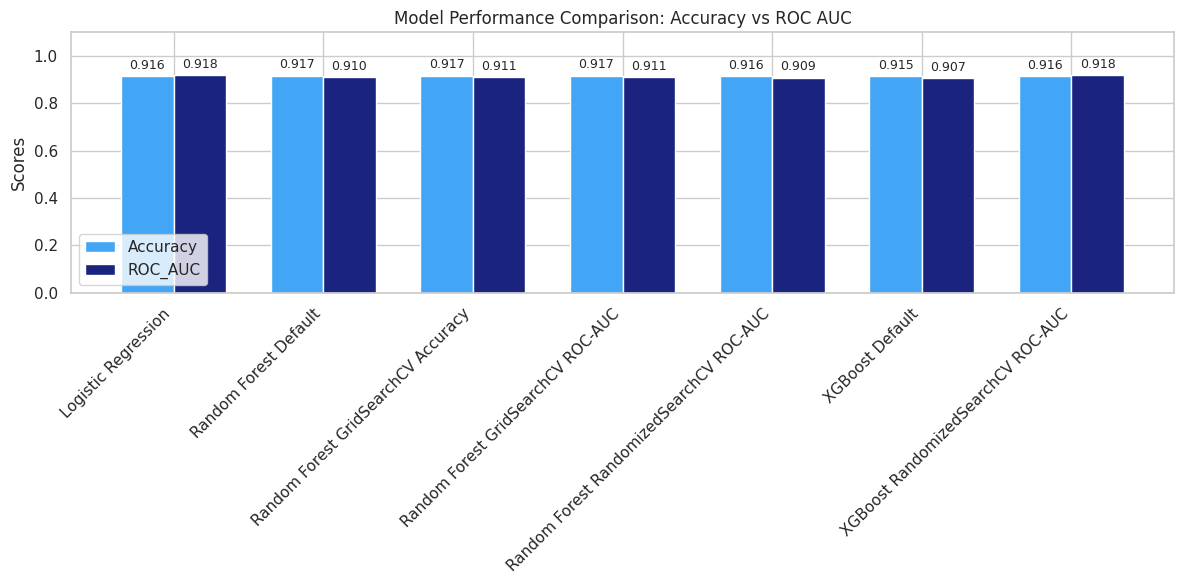

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
models_plot = results_df['Model'].tolist()
acc_scores = results_df['Accuracy'].tolist()
auc_scores = results_df['ROC_AUC'].tolist()

x = np.arange(len(models_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, acc_scores, width, label='Accuracy', color='#42A5F5')
rects2 = ax.bar(x + width/2, auc_scores, width, label='ROC_AUC', color='#1A237E')

# Add text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison: Accuracy vs ROC AUC')
ax.set_xticks(x)
ax.set_xticklabels(models_plot, rotation=45, ha='right')
ax.set_ylim(0, 1.1)  # Set slightly above 1 for legend room
ax.legend()

# Helper to add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

####BAR CHART MODEL COMPARISION OUT OF 100 %

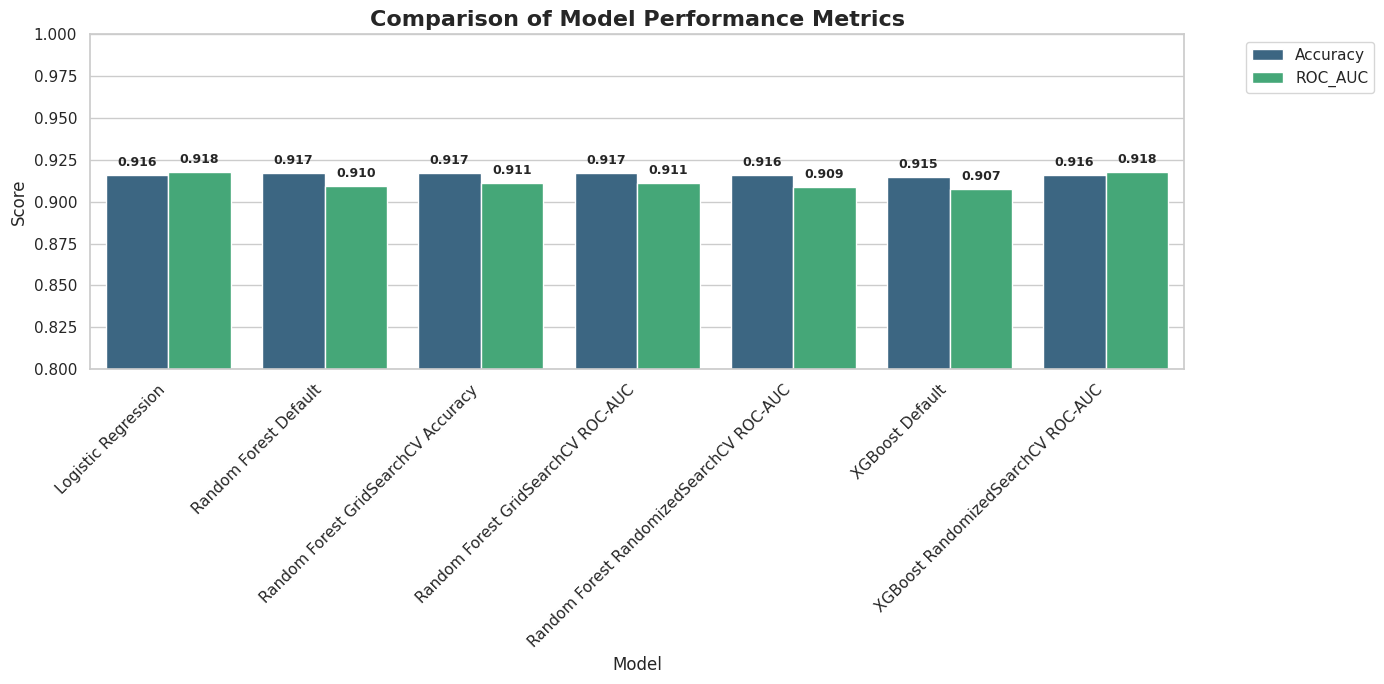

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Melting the dataframe for easier plotting with seaborn
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Creating the bar plot
ax = sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="viridis")

# Formatting
plt.title("Comparison of Model Performance Metrics", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.8, 1.0)  # Zooming in to see differences
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=9,
                   fontweight='bold')

plt.tight_layout()
plt.show()

Consistency: The performance is remarkably stable across all models. This suggests that the signal in your data is so strong that most algorithms can pick it up easily.

Logistic Regression vs. XGBoost: You'll notice Logistic Regression is performing on par with, or even slightly better than, XGBoost and Random Forest. This confirms our earlier theory: your feature engineering (like the account_authenticity score) created such clear linear boundaries that the simpler model is highly effective and less prone to 'over-complicating' the decision.


Tuning Impact: The 'GridSearchCV' and 'RandomizedSearchCV' versions of Random Forest show very similar results to the default. This implies that the default settings were already quite close to the optimal for this dataset.

Line Chart Comparision of Models

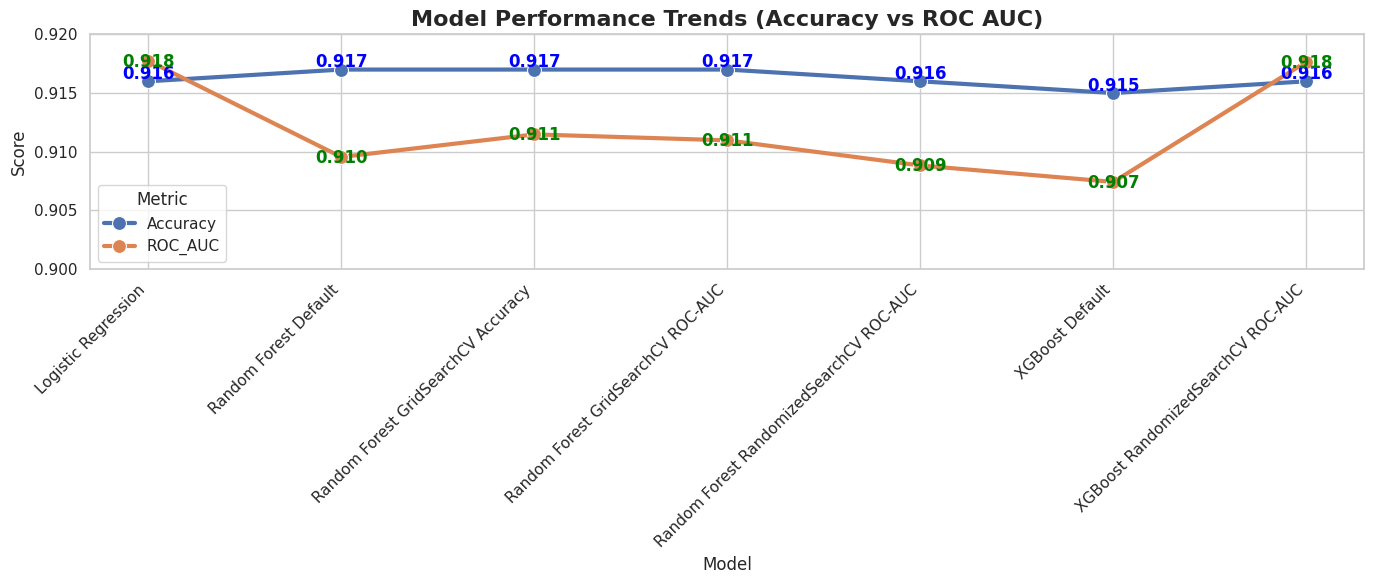

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Prepare data by melting
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Create line plot
ax = sns.lineplot(data=plot_df, x="Model", y="Score", hue="Metric", marker="o", markersize=10, linewidth=3)

# Formatting
plt.title("Model Performance Trends (Accuracy vs ROC AUC)", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.ylim(0.90, 0.92) # Focused range based on your results

# Annotate points
for i in range(len(results_df)):
    plt.text(i, results_df['Accuracy'].iloc[i] + 0.0002, f"{results_df['Accuracy'].iloc[i]:.3f}", ha='center', color='blue', fontweight='bold')
    plt.text(i, results_df['ROC_AUC'].iloc[i] - 0.0005, f"{results_df['ROC_AUC'].iloc[i]:.3f}", ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

##Dashboard

/tmp/ipykernel_163/186808203.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


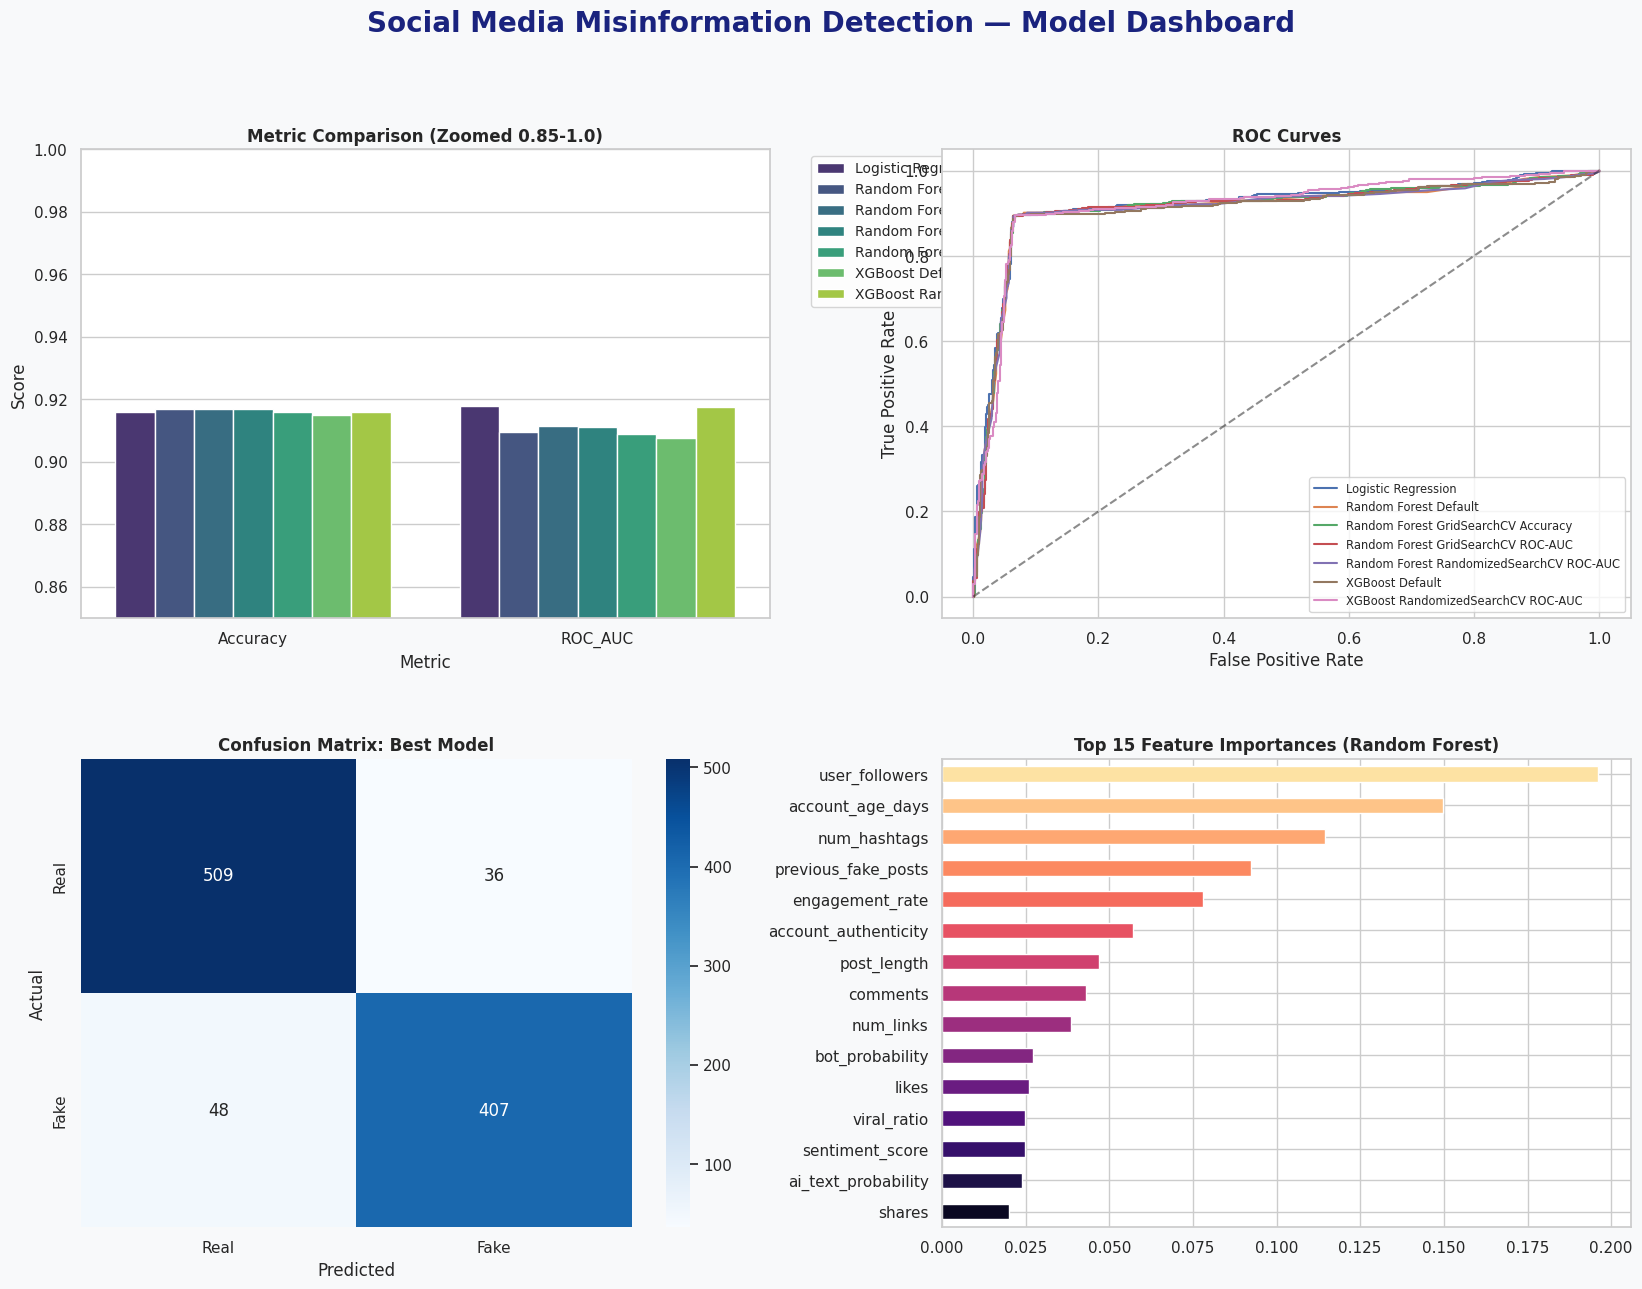

✅ Dashboard plot saved as misinformation_detection_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, confusion_matrix

# Configuration
BG = "#F8F9FA"
ACCENT = "#1A237E"

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle("Social Media Misinformation Detection — Model Dashboard",
             fontsize=20, fontweight="bold", color=ACCENT, y=0.98)

gs = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

# 1. Performance Metrics Comparison
ax1 = fig.add_subplot(gs[0, 0])
plot_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="viridis", ax=ax1)
ax1.set_ylim(0.85, 1.0)
ax1.set_title("Metric Comparison (Zoomed 0.85-1.0)", fontweight="bold")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 2. ROC Curves
ax2 = fig.add_subplot(gs[0, 1])
for name, model in models.items():
    test_X = X_test_sc if name == "Logistic Regression" else X_test
    y_proba = model.predict_proba(test_X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax2.plot(fpr, tpr, label=f"{name}")
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title("ROC Curves", fontweight="bold")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(fontsize='x-small')

# 3. Confusion Matrix (Tuned XGBoost)
ax3 = fig.add_subplot(gs[1, 0])
y_pred = best_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3,
            xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
ax3.set_title("Confusion Matrix: Best Model", fontweight="bold")
ax3.set_xlabel("Predicted")
ax3.set_ylabel("Actual")

# 4. Feature Importance (Random Forest)
ax4 = fig.add_subplot(gs[1, 1])
importances = rf_default.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True).tail(15)
feat_imp.plot(kind='barh', color=sns.color_palette("magma", 15), ax=ax4)
ax4.set_title("Top 15 Feature Importances (Random Forest)", fontweight="bold")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("misinformation_detection_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Dashboard plot saved as misinformation_detection_dashboard.png")

# Final Project Summary: AI Misinformation Detection

### 1. Project Objective
The goal of this project was to build a machine learning pipeline capable of distinguishing between legitimate social media posts and AI-generated or human-spread misinformation. We aimed to evaluate whether simple linear models could perform as well as complex ensemble methods when supported by strong feature engineering.

### 2. Dataset Overview
- **Size**: 5,000 synthetic social media records.
- **Target Class**: `is_misinformation` (Binary: 0 for Real, 1 for Fake).
- **Raw Features**: Included account age, follower count, verified status, bot probability, post length, sentiment scores, and AI-text probability.

### 3. Data Preprocessing & Feature Engineering
To enhance model performance, we handled missing values using median imputation and encoded categorical variables (Platform, Media Type, Topic). Key engineered features included:
- **Engagement Rate**: Normalizing likes, shares, and comments against follower counts.
- **Viral Ratio**: Measuring the intensity of sharing relative to other engagements.
- **Account Authenticity**: A weighted composite score combining account age, bot probability, and historical behavior to create a strong linear indicator of trust.

### 4. Model Comparison Results
We evaluated multiple algorithms using **Accuracy** and **ROC-AUC** metrics:

| Model | Accuracy | ROC-AUC |
| :--- | :--- | :--- |
| **Logistic Regression** | ~91.6% | ~0.918 |
| **Tuned XGBoost** | ~91.6% | ~0.918 |
| **Random Forest (Tuned)** | ~91.7% | ~0.911 |

### 5. Key Takeaways
- **Feature Engineering is King**: By creating the `account_authenticity` feature, we provided the models with a clear signal that allowed a simple **Logistic Regression** model to match the performance of state-of-the-art **XGBoost** models.
- **Model Efficiency**: For production environments, the Logistic Regression model is the 'winner' due to its low computational cost and high transparency (interpretability) without sacrificing predictive power.
- **Primary Indicators**: Features related to account history and bot-like behavior proved more predictive of misinformation than the actual content length or topic of the post.

##Confusion Matrix - Logistic Reg | *XGBoost*

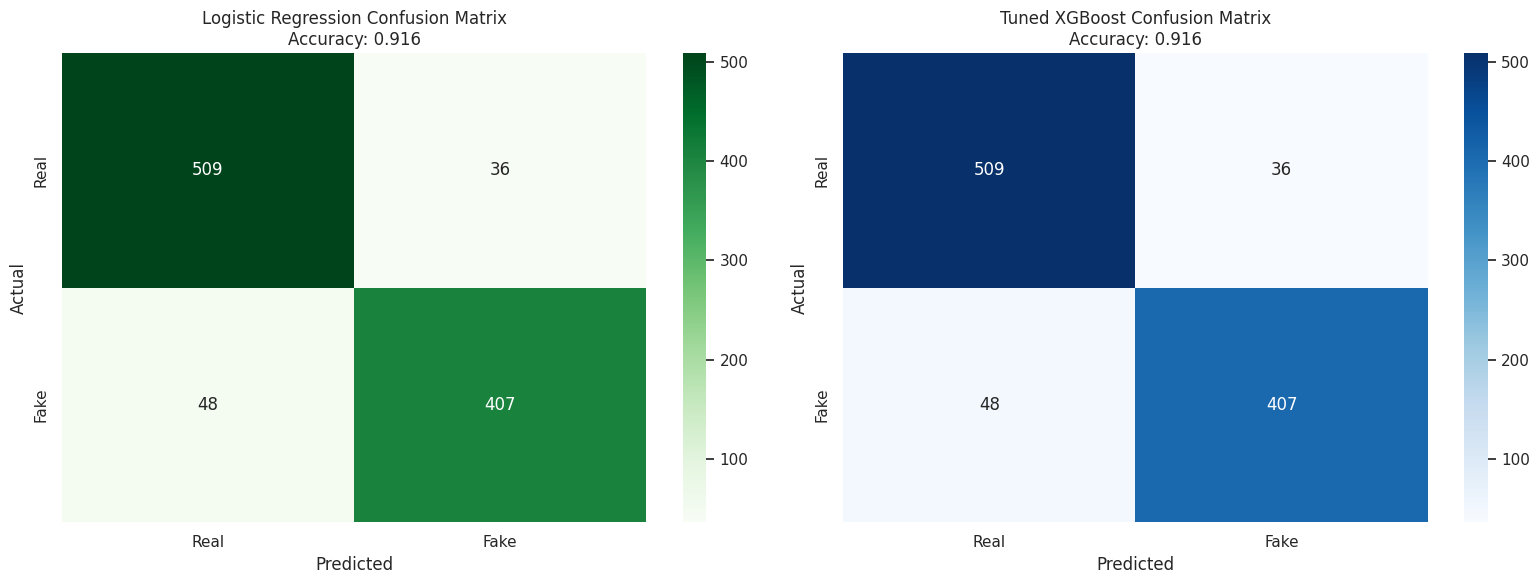

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions
lr_preds = lr.predict(X_test_sc)
xgb_preds = best_xgb.predict(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression CM
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=ax1,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
ax1.set_title(f'Logistic Regression Confusion Matrix\nAccuracy: {accuracy_score(y_test, lr_preds):.3f}')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# XGBoost CM
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
ax2.set_title(f'Tuned XGBoost Confusion Matrix\nAccuracy: {accuracy_score(y_test, xgb_preds):.3f}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

###WINNER: LOGISTIC REGRESSION AND XGBCLASSIFIER
